<a href="https://colab.research.google.com/github/stenoe/FEDS/blob/main/notebooks/class_notebooks_2026/course2026_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Steps towards machine learning

Use "requests" library to load data into the colab virtual machine directly from internet/github...

To do so we need to:

1.   Set a path to a folder in the virtual machine
2.   Create it if it's not existing
3.   Open a file in that folder to write the data into (name of your choice!)
4.   Request data via a REST API with ```get()``` and write them to the file.

This is a code snippet you can reuse to load data into the virtual machine where your Colab Notebook is.

In [2]:
import requests
from pathlib import Path

# setup path to data folder
data_path = Path('data/')

# If the data folder doesn't exist we create it
if data_path.is_dir():
  print(f"{data_path} directory already exists... skipping creation")
else:
  data_path.mkdir(parents=True, exist_ok=True)
  print(f"{data_path} does not exists, creating it...")

  # Download temperature anomaly data
  with open(data_path / "land_global_temperature_anomaly-1850-2003.csv", "wb") as f:
    request = requests.get("https://raw.githubusercontent.com/stenoe/FEDS/refs/heads/main/data/land_global_temperature_anomaly-1850-2023.csv")
    print("Downloading data...")
    f.write(request.content)
    print("-- done!")




data does not exists, creating it...
-- done!


## Let's check what we have downloaded

<Axes: xlabel='Year', ylabel='Value'>

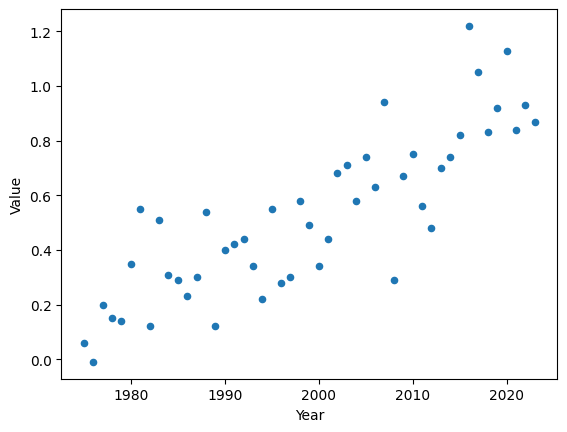

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(data_path / "land_global_temperature_anomaly-1850-2003.csv", skiprows=4)
dfn = df[df.Year >= 1975]
dfn.plot.scatter("Year", "Value")

## Prepare a simple linear regression

We want to obtain a trend for our "unknown" data and use it as our baseline model.

To do so, let's use the np.polyfit() function which is a fast way to run a linear regression in Python.

We calculate $f(x) = mx + b$


In [4]:
reg = np.polyfit(dfn.Year, dfn.Value, 1)
print(reg)
print(f"f(x) = {reg[0]}x + {reg[1]}")

[ 1.73520408e-02 -3.41614235e+01]
f(x) = 0.017352040816326502x + -34.16142346938769


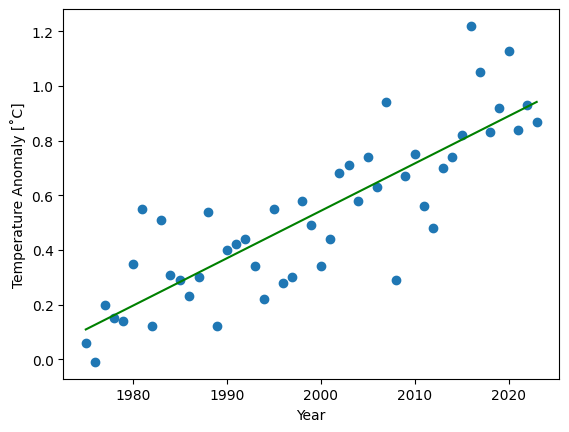

In [15]:
# Visualise the trendline
trend = np.polyval(reg, dfn.Year)
plt.scatter(dfn.Year, dfn.Value)
plt.plot(dfn.Year, trend, color='green')
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly [˚C]")
plt.show()

## Gradient descent introduction

We have the linear function:

$y = wx + b$

We don't know the parameters w and b! We want to learn them from the data. Different from the baseline model approach using a linear regression where we assume that there exist (constant) parameters w and b so we can find the squared sum of errors (deviation from the model) in Gradient descent we minimise the error regardless of the model.

We need to create a "loss function" on which we can minimise the error:

$l = \frac{1}{N}\sum_{i=1}^{N}(y_i - (wx_i + b))^2$

## Gradient descent

We need to differentiate the above equation for w and b!

$\frac{\partial l}{\partial w} = \frac{1}{N}\sum_{i=1}^{N}-2x_i(y_i - (wx_i + b))$

$\frac{\partial l}{\partial b} = \frac{1}{N}\sum_{i=1}^{N}-2(y_i - (wx_i + b))$

Now that we have the gradients, let's update our parameters with them:

$w \leftarrow w - \alpha \frac{\partial l}{\partial w}$

$b \leftarrow b - \alpha \frac{\partial l}{\partial b}$

$\alpha$ is a hyperparameter for the algorithm, and it is aka learning rate.


Let's implement that into a python function:

In [5]:
def update_w_and_b(years, values, w, b, alpha):
  dl_dw = 0.0
  dl_db = 0.0
  N = len(years)

  for i in range(N):
    dl_dw += -2 * years[i] * (values[i] - (w * years[i] + b))
    dl_db += -2 * (values[i] - (w * years[i] + b))

  # update w and b
  w = w - (1/float(N)) * dl_dw * alpha
  b = b - (1/float(N)) * dl_db * alpha

  return w, b




## Build a loss function

To have a decision criteria if the gradient descent is learning we want to minimise the loss in every step, the algorithm can use this function's return value to stop execution if the desired accuracy is reached.

In [6]:
# build a loss function
def avg_loss(years, values, w, b):
  N = len(years)
  total_error = 0.0

  for i in range(N):
    total_error += (values[i] - (w * years[i] + b)) ** 2

  return total_error # / float(N)


## Building a prediction function

The prediction function takes the actual $w$ and $b$ parameters and returns a $y$ for it.

In [7]:
# prediction function
def predict(x, w, b):
  return w*x + b

## Build a training function

The training function loops over the number of given epochs and takes care to update each time the values of the gradient $w$ and $b$ in our case.

In [8]:
# training function

def train(years, values, w, b, alpha, epochs):
  for e in range(epochs):
    w, b = update_w_and_b(years, values, w, b, alpha)

    # log the learning every 400th step
    if e % 400 == 0:
      print(f"epoch: {e} loss: {avg_loss(years, values, w, b)} w: {w} b: {b}")

  return w, b

## Run the gradient decent and make a prediction with the learned parameters

In [9]:
# trainig loop

# run the gradient decent algorithm
# inintialise alpha = 0.001, w = 0.0, b = 0.0

w, b = train((dfn.Year-1975).to_list(),
             dfn.Value.to_list(),
             0.0, 0.0, 0.001, 15000)

x_new = 27
y_new = predict(x_new, w, b)
print(f"\nPrediction for {x_new+1975} is {y_new}")

epoch: 0 loss: 6.3524963618285755 w: 0.03215551020408164 b: 0.0010506122448979591
epoch: 400 loss: 1.3017512725111478 w: 0.020075253869057785 b: 0.02083580365647573
epoch: 800 loss: 1.268705872683487 w: 0.019568189645940707 b: 0.03722544013194228
epoch: 1200 loss: 1.24682091976631 w: 0.0191555411447619 b: 0.0505633145433762
epoch: 1600 loss: 1.2323271879099889 w: 0.01881972809039501 b: 0.06141766717538721
epoch: 2000 loss: 1.222728434651623 w: 0.018546443667548273 b: 0.0702509315641301
epoch: 2400 loss: 1.2163714753102775 w: 0.01832404500019607 b: 0.07743943578973643
epoch: 2800 loss: 1.21216145646931 w: 0.01814305712417732 b: 0.08328943537396899
epoch: 3200 loss: 1.209373290352528 w: 0.017995769320451854 b: 0.08805016084083526
epoch: 3600 loss: 1.2075267736055908 w: 0.017875906611393808 b: 0.09192443581206011
epoch: 4000 loss: 1.2063038823021632 w: 0.017778362424710734 b: 0.09507731800556778
epoch: 4400 loss: 1.2054939989677835 w: 0.01769898103553277 b: 0.09764313127384867
epoch: 4800

## Predict multiple values from the model

We can use the numpy ``linspace()`` function to generate a  set of data

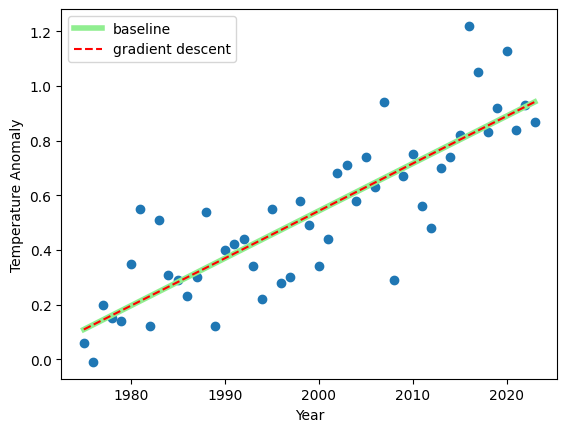

In [27]:
# lets plot a predicted estimator

xn = np.linspace(0,2023-1975, 100)
yn = predict(xn, w, b)

plt.scatter(dfn.Year, dfn.Value)
plt.plot(dfn.Year, trend, color='lightgreen', linewidth=4, label="baseline")
plt.plot(xn+1975, yn, color="red", linestyle="--", label="gradient descent")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly")
plt.legend()
plt.show()

## Use scikit learn builtin ML algorithm

In [11]:
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# load the dataset and reshape it to fit the needs of the algorithm
X, y = np.array(dfn.Year-1975).reshape(-1, 1), np.array(dfn.Value)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)

# Create the gradient decent model
sdg_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.001)

# train the model
sdg_reg.fit(X_train, y_train)

# make prediction
y_pred = sdg_reg.predict(X_test)

# evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")



Mean Squared Error: 0.025401668036013757


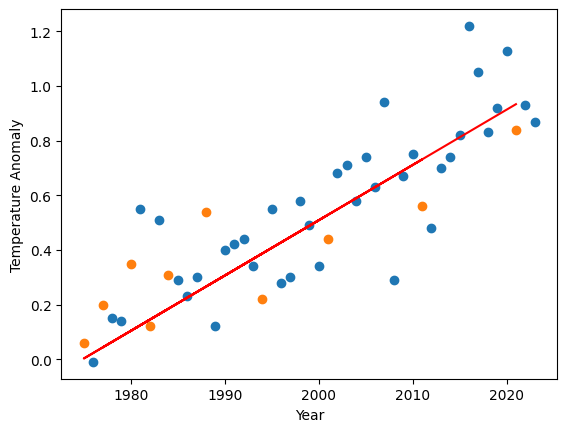

In [12]:
plt.scatter(X_train+1975, y_train)
plt.scatter(X_test+1975, y_test)
plt.plot(X_test+1975, y_pred, color="red")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly")
plt.show()